In [41]:
# Обработка данных
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot


# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Модели ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Модель Prophet
import prophet as fp
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import add_changepoints_to_plot

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL as STL_decomp, MSTL as MSTL_decomp

# Настройка
import itertools
from tqdm import tqdm

import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

from statsforecast import StatsForecast
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
!pip install statsforecast

In [7]:
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL,
    AutoARIMA,
    SeasonalNaive,
    HistoricAverage,
    AutoETS,
    AutoTBATS,
    AutoCES,
    AutoTheta,
    HoltWinters
  )

from utilsforecast.losses import rmse, mape
from utilsforecast.evaluation import evaluate

In [8]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

Метрики возьмем RMSЕ, так как алкоголь имеет сезонные пики, важно не сильно ошибаться в эти периоды, а данная метрика чувствительна к большим ошибкам(квадратично штрафует за ошибки), и MAPE это удобная и понятная метрика, показывает на сколько процентов мы ошибаемся

In [42]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    return  float(round(rmse, 2)), float(round(mape, 2))

Временной ряд продажи алкоголя в США с 1994 года по 2025

In [10]:
df = pd.read_csv('alcohol.csv', parse_dates=['observation_date'])
df.columns = ['ds','y']
df = df.set_index('ds')
df

,y
ds,
1994-01-01,3075
1994-02-01,3377
1994-03-01,4443
1994-04-01,4261
1994-05-01,4460
...,...
2025-04-01,15349
2025-05-01,15997
2025-06-01,16849


In [11]:
fig = px.line(df, x=df.index, y=df['y'], title="Продажа алкоголя в США")
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="обьем продаж млн.$")
fig.show()

Как видим из графика, аременной ряд имеет восходящий тренд и явную сезонность. Причем дисперсия из года в год возрастает, что указывает на мультипликативность ряда.

In [12]:
train_size = int(len(df)*0.8)
train, test = df[:train_size], df[train_size:]

train.reset_index(inplace=True)
test.reset_index(inplace=True)

In [13]:
fig = px.line(title="Продажи алкоголя в США")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="обьем продаж млн.$")
fig.show()

Мой временной ряд демонстрирует мультипликативный характер : имеет тренд и со временем увеличивается дисперсия, поэтому для декомпозиции будем использовать MSTL, применяя предварительное логарифмическое преобразование данных, так как по умолчанию MSTL предполагает аддитивность, а мой временной ряд имеет мультипликативный характер

In [14]:
train['log_y'] = np.log(train['y'])

fig = px.line(train, x=train.ds, y=train.log_y,
              title="Прологарифмированный временной ряд")

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.show()

Как видим из графика прологарифмированного временного ряда, тренд сохранился, а вот дисперсия выровнилась

MSTL разложение брала по 4 , 6 и 12 месяцам соответсвенно. Подбирала вручную, опираясь на визуальную корректность

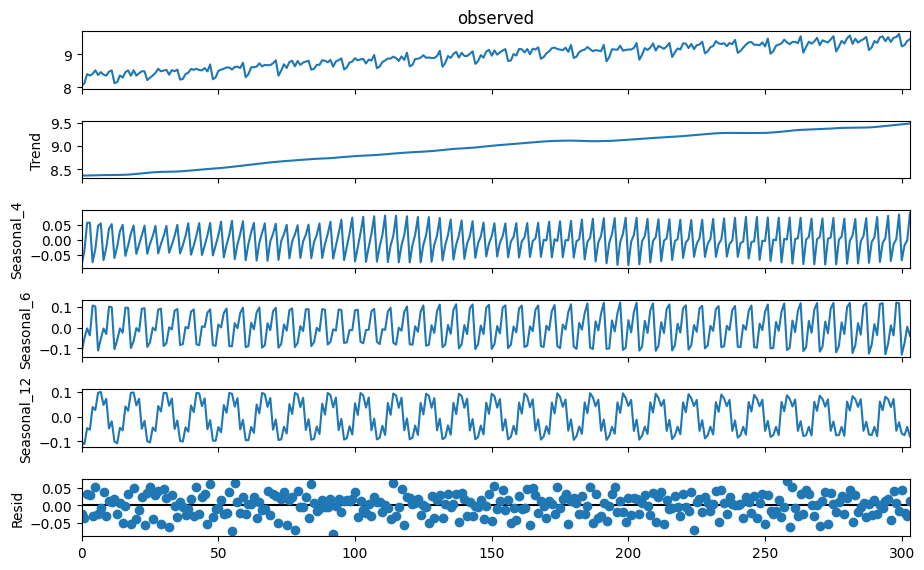

<Axes: >

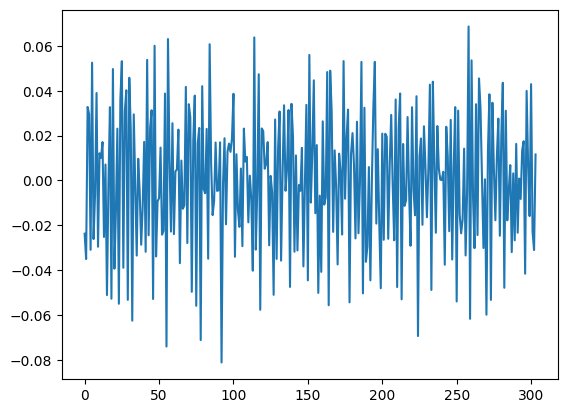

In [15]:
mstl_multi = MSTL_decomp(train['log_y'], periods=(4,6,12))
res_multi = mstl_multi.fit()

fig = res_multi.plot()
fig.set_size_inches(10, 6)
plt.show()

res_multi.resid.plot()

Разложение MSTL с периодами 4, 6 и 12 месяцев выглядит корректным: тренд выделен, а три сезонные компоненты явно улавливают повторяющиеся паттерны с разной частотой. Компонента seasonal_4 показывает частые колебания небольшой амплитуды,есть чётко повторяющийся паттерн с периодом 4 месяца. Такое же поведение у seasonal_6 и seasonal_12, это означает, что выбранные периоды 4, 6 и 12 хорошо объяснили сезонность.Остатки выглядят визуально как шум, без заметного тренда и их дисперсия примерно постоянна по всей длине ряда.

In [16]:
acorr_ljungbox(res_multi.resid, return_df=True)

,lb_stat,lb_pvalue
1,73.603170,9.551117e-18
2,73.678143,1.002293e-16
3,122.109592,2.710615e-26
4,192.478662,1.554647e-40
5,197.193608,1.131619e-40
6,202.124320,6.698890e-41
7,211.847099,3.541324e-42
8,218.222589,9.141540e-43
9,264.563181,8.355921e-52
10,325.470709,6.329801e-64


Из теста Льюнга-Бокса видем , что наши остатки автокоррелированы до 10 лага

In [17]:
adf_test(res_multi.resid)

Results of Dickey-Fuller Test:
Test Statistic                -7.418218e+00
p-value                        6.845357e-11
#Lags Used                     1.500000e+01
Number of Observations Used    2.880000e+02
Critical Value (1%)           -3.453262e+00
Critical Value (5%)           -2.871628e+00
Critical Value (10%)          -2.572146e+00
dtype: float64


ADF тест показывает, что ряд стационарен, так как мы отказываемся от нулевой гипотезы(которая утверждает, что ряд не стационарен) p-value < 0.05. То есть, в целом, остатки не плохие, стационарные и автокоррелированные, лучше конечно же было бы, что бы были не автокоррелированы. По этому попробуем смоделировать остатки с помощью auto ARIMA,что она подобрала коэффициенты самостоятельно, а затем проверить остатки остатков на автокорреляцию и стационарность.

In [18]:
resid = res_multi.resid.dropna()

In [19]:
!pip install pmdarima

import pmdarima as pm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.6 MB/s eta 0:00:00


# ТУТ автоариму настроить

In [20]:
auto_model = pm.auto_arima(
    resid,
    seasonal=False,
    d=None,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())
arima_resid = auto_model.resid()


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1249.912, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1331.191, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1343.265, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1346.462, Time=0.82 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-1438.790, Time=2.40 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-1366.410, Time=0.64 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-1400.909, Time=1.99 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1422.869, Time=1.80 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-1350.686, Time=1.14 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-1399.387, Time=0.43 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=2.63 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-1436.798, Time=2.42 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 14.437 seconds
                               SARIMAX Results                                
De

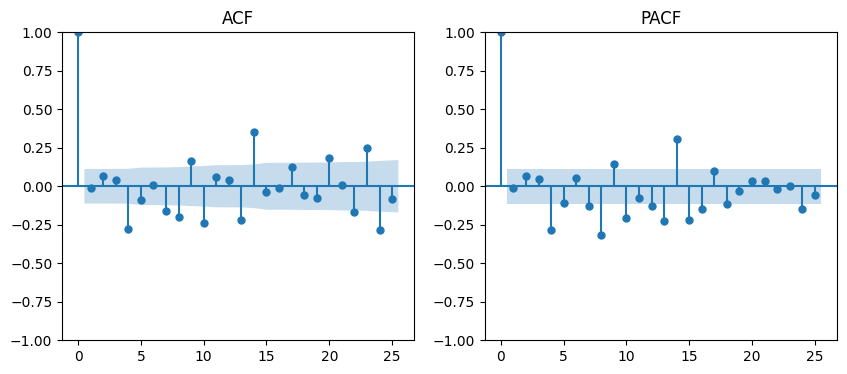

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(arima_resid, ax=ax[0])
ax[0].set_title('ACF')
plot_pacf(arima_resid, ax=ax[1])
ax[1].set_title('PACF')
plt.show()



Визуально автокорреляция отсутствует, значимых лагов нет

In [22]:
acorr_ljungbox(arima_resid, return_df=True)

,lb_stat,lb_pvalue
1,0.031353,8.594548e-01
2,1.538139,4.634441e-01
3,2.127620,5.463453e-01
4,25.678851,3.673046e-05
5,28.278933,3.210208e-05
6,28.293694,8.271909e-05
7,36.464914,5.922269e-06
8,48.953655,6.489164e-08
9,57.681933,3.740497e-09
10,75.500680,3.801191e-12


как видим остатки остатков с помощью auto ARIMA удалось сделать не автокоррелированными до 5 лага

In [23]:
adf_test(arima_resid)

Results of Dickey-Fuller Test:
Test Statistic                -6.006964e+00
p-value                        1.606936e-07
#Lags Used                     1.600000e+01
Number of Observations Used    2.870000e+02
Critical Value (1%)           -3.453342e+00
Critical Value (5%)           -2.871664e+00
Critical Value (10%)          -2.572164e+00
dtype: float64


А так же ADF тест показывает, что остатки остатков стационарны. Значит нам удалось учесть все паттерны

In [24]:
train['y_restored'] = np.exp(train['log_y'])

In [25]:
train.drop(['log_y', 'y_restored'], axis=1, inplace=True)

In [26]:
train['unique_id'] = 'alcohol_sale'
train

,ds,y,unique_id
0,1994-01-01,3075,alcohol_sale
1,1994-02-01,3377,alcohol_sale
2,1994-03-01,4443,alcohol_sale
3,1994-04-01,4261,alcohol_sale
4,1994-05-01,4460,alcohol_sale
...,...,...,...
299,2018-12-01,15135,alcohol_sale
300,2019-01-01,10353,alcohol_sale
301,2019-02-01,10764,alcohol_sale
302,2019-03-01,12228,alcohol_sale


# Модель SARIMA

In [81]:
models = [AutoARIMA(seasonal=True, season_length = 24, approximation=True)]
sf = StatsForecast(models=models, freq='M', n_jobs=-1)

sf.fit(df=train)
result = sf.fitted_[0][0].model_
forecast = sf.predict(h=len(test))

forecast.columns = ['unique_id', 'ds', 'y_hat']

fig = px.line(title="Alcohol Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='forecast', line=dict(color='fuchsia'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Date")
fig.update_yaxes(title_text="Sales")
fig.show()
sarima_metric = metrics(test['y'].values, forecast['y_hat'].values)
sarima_metric

RMSE: 1598.56
MAPE: 8.39%


(1598.56, 8.39)

# Модель SARIMAX с непрерывным регрессором уровень безработицыи dummy регрессором празничные дни

В качестве непрерывного регрессора возьмем уровень безработицы в США. Логика такая что при росте безработицы люди начинают экономить:кто-то переходит на более дешевые марки или покупает алкоголь домой вместо баров. А так же при росте безработицы у людей освобождается время и повышается уровень стресса и тревоги, и для некоторых людей это может послужить поводом к увеличению потребления алкоголя

In [27]:
unemploy = pd.read_csv('unemployment_rate_monthly.csv', parse_dates=['date'])
unemploy.columns = ['ds','unemployment']
unemploy = unemploy.set_index('ds')
unemploy = unemploy.loc[df.index.min():df.index.max()]
unemploy

,unemployment
ds,
1994-01-01,6.6
1994-02-01,6.6
1994-03-01,6.5
1994-04-01,6.4
1994-05-01,6.1
...,...
2025-04-01,4.2
2025-05-01,4.2
2025-06-01,4.1


In [28]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['y'],
    mode='lines',
    name='y',
    line=dict(color='blue'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=unemploy.index,
    y=unemploy['unemployment'],
    mode='lines',
    name='уровень безработицы',
    line=dict(color='red'),
    yaxis='y2'
))


fig.update_layout(
    title="Продажи алкоголя в США и уровень безработицы",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='продажи алкоголя в США',
    ),
    yaxis2=dict(
        title='уровень безработицы',
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Дата')
)

fig.show()

Как видим из совместного графика продаж алкоголя и уровнем безработицы демонстрируют разную динамику и не имеют явной сильной корреляции. Есть пик безработицы в годы ковида, что логично. Уровень безработицы со временем расширяет амплитуду колебания, и имеет некую схожесть в тренде до примерно 2013 года

In [29]:
# Месяцы с основными праздниками
holiday_months = [1, 7, 9, 11, 12]  # январь, июль, сентябрь, ноябрь, декабрь

holidays_dummy = pd.DataFrame(index=df.index)
holidays_dummy['main_holiday'] = holidays_dummy.index.month.isin(holiday_months).astype(int)

regressors = pd.merge(
    unemploy[['unemployment']],
    holidays_dummy[['main_holiday']],
    left_index=True, right_index=True,
    how='inner'
)
regressors['unique_id'] = 'alcohol_sale'

regressors


,unemployment,main_holiday,unique_id
ds,,,
1994-01-01,6.6,1,alcohol_sale
1994-02-01,6.6,0,alcohol_sale
1994-03-01,6.5,0,alcohol_sale
1994-04-01,6.4,0,alcohol_sale
1994-05-01,6.1,0,alcohol_sale
...,...,...,...
2025-04-01,4.2,0,alcohol_sale
2025-05-01,4.2,0,alcohol_sale
2025-06-01,4.1,0,alcohol_sale


In [30]:
split_idx = int(len(regressors) * 0.8)
regressors_train = regressors.iloc[:split_idx].copy()
regressors_test = regressors.iloc[split_idx:].copy()
regressors_train = regressors_train.reset_index()
regressors_test = regressors_test.reset_index()
regressors_test

,ds,unemployment,main_holiday,unique_id
0,2019-05-01,3.6,0,alcohol_sale
1,2019-06-01,3.6,0,alcohol_sale
2,2019-07-01,3.7,1,alcohol_sale
3,2019-08-01,3.6,0,alcohol_sale
4,2019-09-01,3.5,1,alcohol_sale
...,...,...,...,...
71,2025-04-01,4.2,0,alcohol_sale
72,2025-05-01,4.2,0,alcohol_sale
73,2025-06-01,4.1,0,alcohol_sale
74,2025-07-01,4.2,1,alcohol_sale


In [31]:
forecast_horizon = len(df) - train_size
forecast_horizon

76

Выберем на основе метрики RMSE лучший период для модели SARIMAX

In [60]:
best_season_length = None
best_rmse = float('inf')
best_mape = float('inf')

for season_len in [3, 6, 12, 24, 36]:
    models = [AutoARIMA(seasonal=True, season_length=season_len, approximation=True)]
    sf = StatsForecast(models=models, freq='M', n_jobs=-1)

    forecast_best = sf.forecast(df=train.merge(regressors_train, how='left', on=['unique_id', 'ds']),
                           X_df=regressors_test, h=forecast_horizon)
    forecast_best.columns = ['unique_id', 'ds', 'y_hat']
    rmse, mape = metrics(test['y'].values, forecast_best['y_hat'].values)

    if rmse < best_rmse:
        best_rmse = rmse
        best_mape = mape
        best_season_length = season_len

print(f"Лучший season_length: {best_season_length}, RMSE: {best_rmse:.2f}, MAPE: {best_mape:.2f}%")

RMSE: 2199.16
MAPE: 12.33%
RMSE: 1789.38
MAPE: 9.65%
RMSE: 1474.85
MAPE: 7.72%
RMSE: 1465.43
MAPE: 7.59%
RMSE: 1590.89
MAPE: 8.50%
Лучший season_length: 24, RMSE: 1465.43, MAPE: 7.59%


In [61]:
models = [AutoARIMA(seasonal=True, season_length = 24, approximation=True)]
sf_with_reg = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_with_reg = sf_with_reg.forecast(df=train.merge(regressors_train, how='left', on=['unique_id', 'ds']),
                                         X_df=regressors_test, h=forecast_horizon)

In [62]:
forecast_with_reg.columns = ['unique_id', 'ds', 'y_hat']
forecast_with_reg

,unique_id,ds,y_hat
0,alcohol_sale,2019-04-30,13888.745102
1,alcohol_sale,2019-05-31,14339.463674
2,alcohol_sale,2019-06-30,13300.734787
3,alcohol_sale,2019-07-31,13414.347424
4,alcohol_sale,2019-08-31,13059.384048
...,...,...,...
71,alcohol_sale,2025-03-31,14722.256693
72,alcohol_sale,2025-04-30,16037.753876
73,alcohol_sale,2025-05-31,16957.562144
74,alcohol_sale,2025-06-30,14947.221096


In [80]:

fig = px.line(title="Продажи алкоголя в США SARIMAX модель ")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выбока', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='предсказание без регрессора', line=dict(color='fuchsia'))
fig.add_scatter(x=forecast_with_reg['ds'], y=forecast_with_reg['y_hat'], mode='lines', name='предсказание с регрессорами', line=dict(color='orange'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()
sarimax_metric = metrics(test['y'].values, forecast_with_reg['y_hat'].values)
sarimax_metric

RMSE: 1465.43
MAPE: 7.59%


(1465.43, 7.59)

Визуально модель с регрессорами хорошо уловила динамику фактического ряда: это подтверждается невысоким RMSE 1465.43 и относительно небольшим процентом отклонения 7.59%, в целом модель справилась с задачей и захватила основные паттерны. Так же видно, что модель немного недооценивает пики продаж в периоды сильной сезонности. Модель с регрессором справилась лучше , нежели без регрессора, процент ошибки  чуть меньше относительно можеди без регрессора на 0.8%

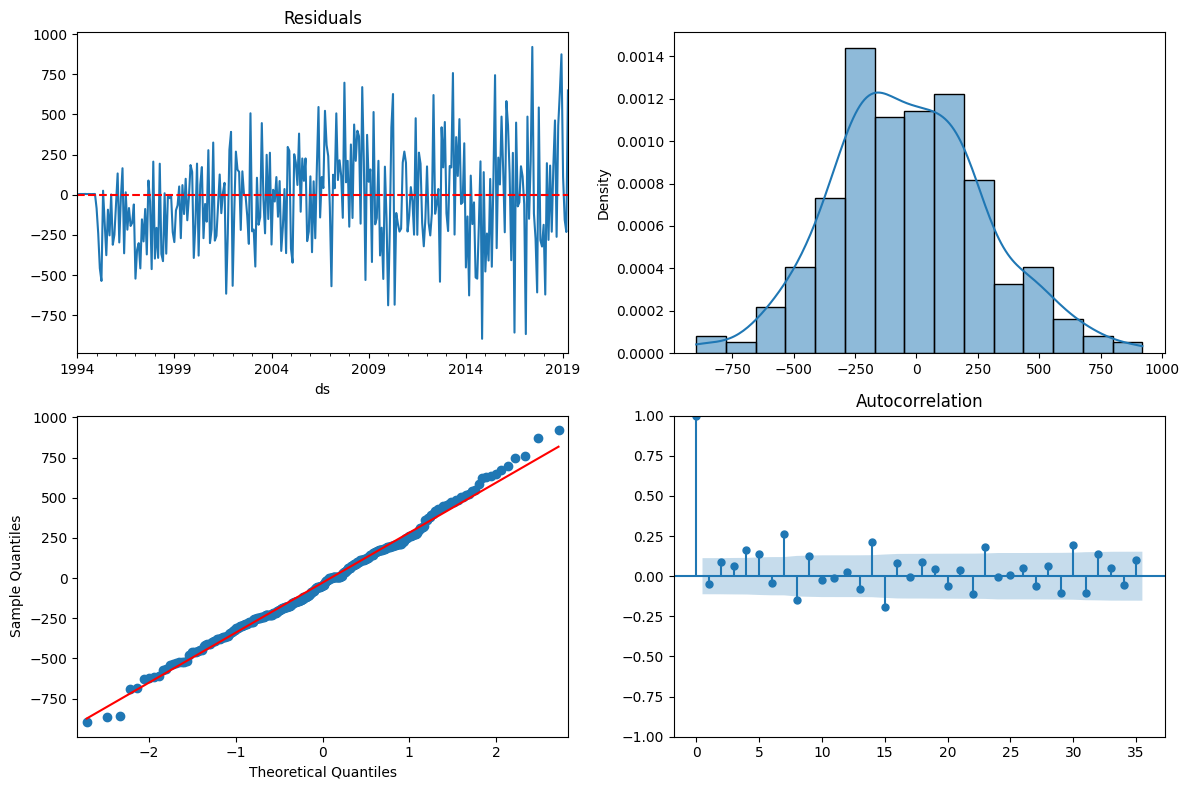

In [71]:


models = [AutoARIMA(seasonal=True, season_length=12, approximation=True)]
sf = StatsForecast(models=models, freq='M', n_jobs=-1)

train_with_reg = train.merge(regressors_train, how='left', on=['unique_id', 'ds'])
sf.fit(train_with_reg)

model_fitted = sf.fitted_[0][0]
residuals = model_fitted.model_['residuals']
residuals_series = pd.Series(residuals, index=train['ds'])

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
residuals_series.plot(ax=axs[0, 0], title='Residuals')
axs[0, 0].axhline(0, color='r', linestyle='--')
sns.histplot(residuals_series, kde=True, ax=axs[0, 1], stat='density')
qqplot(residuals_series, line='s', ax=axs[1, 0])
plot_acf(residuals_series.dropna(), lags=35, ax=axs[1, 1])
plt.tight_layout()
plt.show()

# Prophet

In [98]:
train_fp = train[['ds', 'y']]
test_fp = test[['ds', 'y']]

m = fp.Prophet()
m.fit(train_fp)
future = m.make_future_dataframe(periods=forecast_horizon, freq='M')
forecast_prophet = m.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [99]:
train_fp_with_reg = regressors.join(train_fp.set_index('ds'), how='inner')[['unemployment','y']].reset_index()
train_fp_with_reg


,ds,unemployment,y
0,1994-01-01,6.6,3075
1,1994-02-01,6.6,3377
2,1994-03-01,6.5,4443
3,1994-04-01,6.4,4261
4,1994-05-01,6.1,4460
...,...,...,...
299,2018-12-01,3.9,15135
300,2019-01-01,4.0,10353
301,2019-02-01,3.8,10764
302,2019-03-01,3.8,12228


In [100]:
forecast_prophet.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1994-01-01,4053.906118,1529.002473,2738.060865,4053.906118,4053.906118,-1897.527191,-1897.527191,-1897.527191,-1897.527191,-1897.527191,-1897.527191,0.0,0.0,0.0,2156.378926
1,1994-02-01,4077.173581,2053.732261,3270.242805,4077.173581,4077.173581,-1416.662501,-1416.662501,-1416.662501,-1416.662501,-1416.662501,-1416.662501,0.0,0.0,0.0,2660.511081
2,1994-03-01,4098.189355,3307.087214,4473.138663,4098.189355,4098.189355,-211.828297,-211.828297,-211.828297,-211.828297,-211.828297,-211.828297,0.0,0.0,0.0,3886.361058
3,1994-04-01,4121.456819,3259.678430,4456.930749,4121.456819,4121.456819,-258.641522,-258.641522,-258.641522,-258.641522,-258.641522,-258.641522,0.0,0.0,0.0,3862.815297
4,1994-05-01,4143.973719,4082.283847,5214.256624,4143.973719,4143.973719,497.976635,497.976635,497.976635,497.976635,497.976635,497.976635,0.0,0.0,0.0,4641.950354


In [101]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [87]:
df_cv = cross_validation(m, initial='365.25 days', period='90 days', horizon = '180 days')

INFO:prophet:Making 97 forecasts with cutoffs between 1995-02-06 00:00:00 and 2018-10-03 00:00:00


  0%|          | 0/97 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 17.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 22.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [88]:
res = performance_metrics(df_cv, rolling_window = 1)
res

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,180 days,322731.660497,568.094764,436.644134,0.05467,0.046776,0.055481,0.444251


In [91]:

# Основные месяцы с праздниками
holiday_months = [1, 7, 9, 11, 12]  # январь, июль, сентябрь, ноябрь, декабрь

# Создаем список дат
holiday_list = []
for year in range(1994, 2026):  # твой период
    for month in holiday_months:
        # Ставим на 15-е число месяца (середина)
        date = pd.Timestamp(year=year, month=month, day=15)
        holiday_list.append({
            'holiday': 'main_holiday',
            'ds': date
        })

holidays_prophet = pd.DataFrame(holiday_list)

print("Праздники для Prophet:")
print(holidays_prophet.head())
print(f"\nВсего праздников: {len(holidays_prophet)}")

Праздники для Prophet:
        holiday         ds
0  main_holiday 1994-01-15
1  main_holiday 1994-07-15
2  main_holiday 1994-09-15
3  main_holiday 1994-11-15
4  main_holiday 1994-12-15

Всего праздников: 160


In [ ]:
#forecast_final['unique_id'] = 'sales'

#evaluation_prophet_final = evaluate(
    #test.merge(forecast_final[['unique_id','ds','yhat']]),
    #metrics=metrics,
    #train_df=train
#)
#evaluation_prophet_final

In [ ]:
#print('Adjusted Prophet:')
#display(evaluation_prophet_final)

In [90]:
param_grid = {
    'changepoint_prior_scale': [0.05,0.1,0.5],
    'seasonality_prior_scale': [0.001,0.1,10.0],
    'seasonality_mode':['multiplicative','additive'],
    'holidays_prior_scale':[1.0,5.0,10.0]
}

# Создать все комбинации параметров
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

In [94]:
mapes = []

# Cross validation
for params in tqdm(all_params):
    m = fp.Prophet(**params, holidays=holidays_prophet)  # Fit model with given params
    m.add_regressor('unemployment', mode=params['seasonality_mode'])
    m.fit(train_fp_with_reg)
    df_cv = cross_validation(m, initial='365.25 days', period='180 days', horizon = '180 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    mapes.append(df_p['mape'].values[0])

  0%|          | 0/54 [00:00<?, ?it/s]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 49 forecasts with cutoffs between 1995-02-06 00:00:00 and 2018-10-03 00:00:00


  0%|          | 0/49 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
  2%|▏         | 1/54 [00:11<09:50, 11.15s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 49 forecasts with cutoffs between 1995-02-06 00:00:00 and 2018-10-03 00:00:00


  0%|          | 0/49 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
  4%|▎         | 2/54 [00:22<09:44, 11.25s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 49 forecasts with cutoffs between 1995-02-06 00:00:00 and 2018-10-03 00:00:00


...

INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
 96%|█████████▋| 52/54 [26:40<02:08, 64.21s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 49 forecasts with cutoffs between 1995-02-06 00:00:00 and 2018-10-03 00:00:00


  0%|          | 0/49 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
 98%|█████████▊| 53/54 [27:52<01:06, 66.64s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 49 forecasts with cutoffs between 1995-02-06 00:00:00 and 2018-10-03 00:00:00


  0%|          | 0/49 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
100%|██████████| 54/54 [29:04<00:00, 32.31s/it]


In [95]:
# Найти лучшие параметры
tuning_results = pd.DataFrame(all_params)
tuning_results['mape'] = mapes
tuning_results.sort_values(by='mape')

,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,holidays_prior_scale,mape
8,0.05,0.100,multiplicative,10.0,0.039472
25,0.10,0.100,multiplicative,5.0,0.039651
24,0.10,0.100,multiplicative,1.0,0.041398
26,0.10,0.100,multiplicative,10.0,0.041893
7,0.05,0.100,multiplicative,5.0,0.042053
6,0.05,0.100,multiplicative,1.0,0.042942
43,0.50,0.100,multiplicative,5.0,0.049171
42,0.50,0.100,multiplicative,1.0,0.049423
27,0.10,0.100,additive,1.0,0.051218
28,0.10,0.100,additive,5.0,0.051291


In [96]:
best_params = all_params[tuning_results.sort_values(by='mape').index[0]]
best_params

{'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 0.1,
 'seasonality_mode': 'multiplicative',
 'holidays_prior_scale': 10.0}

In [97]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_tuned = fp.Prophet(holidays=holidays_prophet, **best_params)

# 2. Добавить регрессор
m_tuned.add_regressor('unemployment')

# 3. Обучить модель
m_tuned.fit(train_fp_with_reg)

# 4. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_tuned.make_future_dataframe(periods=forecast_horizon, freq='M')
future['unemployment'] = regressors['unemployment'].values[:1684] # Future regressor values

# 5. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_tuned = m_tuned.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [98]:
fig = px.line(title="Продажи")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_tuned['ds'], y=forecast_tuned['yhat'], mode='lines', name='forecast tuned', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

In [99]:
models = [
    MSTL(
        season_length=[3,6, 12], # определить сезонные периоды
        trend_forecaster=AutoARIMA()
        # (method='CSS-ML') # могут быть разные модели, но давайте пока используем AutoARIMA
        )
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['MSTL'], mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [104]:
models = [
    AutoTheta(season_length=4)
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['AutoTheta'], mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [109]:
models = [
    HoltWinters(season_length=12)
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['HoltWinters'], mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()